Dataset Shape: (388, 13)

First 5 Rows:
    Age  Gender Marital Status Occupation  Monthly Income  \
0   20  Female         Single    Student       No Income   
1   24  Female         Single    Student  Below Rs.10000   
2   22    Male         Single    Student  Below Rs.10000   
3   22  Female         Single    Student       No Income   
4   22    Male         Single    Student  Below Rs.10000   

  Educational Qualifications  Family size Customer Type  latitude  longitude  \
0              Post Graduate            4      Frequent   12.9766    77.5993   
1                   Graduate            3       Regular   12.9770    77.5773   
2              Post Graduate            3       Regular   12.9551    77.6593   
3                   Graduate            6      Frequent   12.9473    77.5616   
4              Post Graduate            4      Frequent   12.9850    77.5533   

   Pin code Output  Feedback  
0    560001    Yes  Positive  
1    560009    Yes  Positive  
2    560017    Yes  Nega

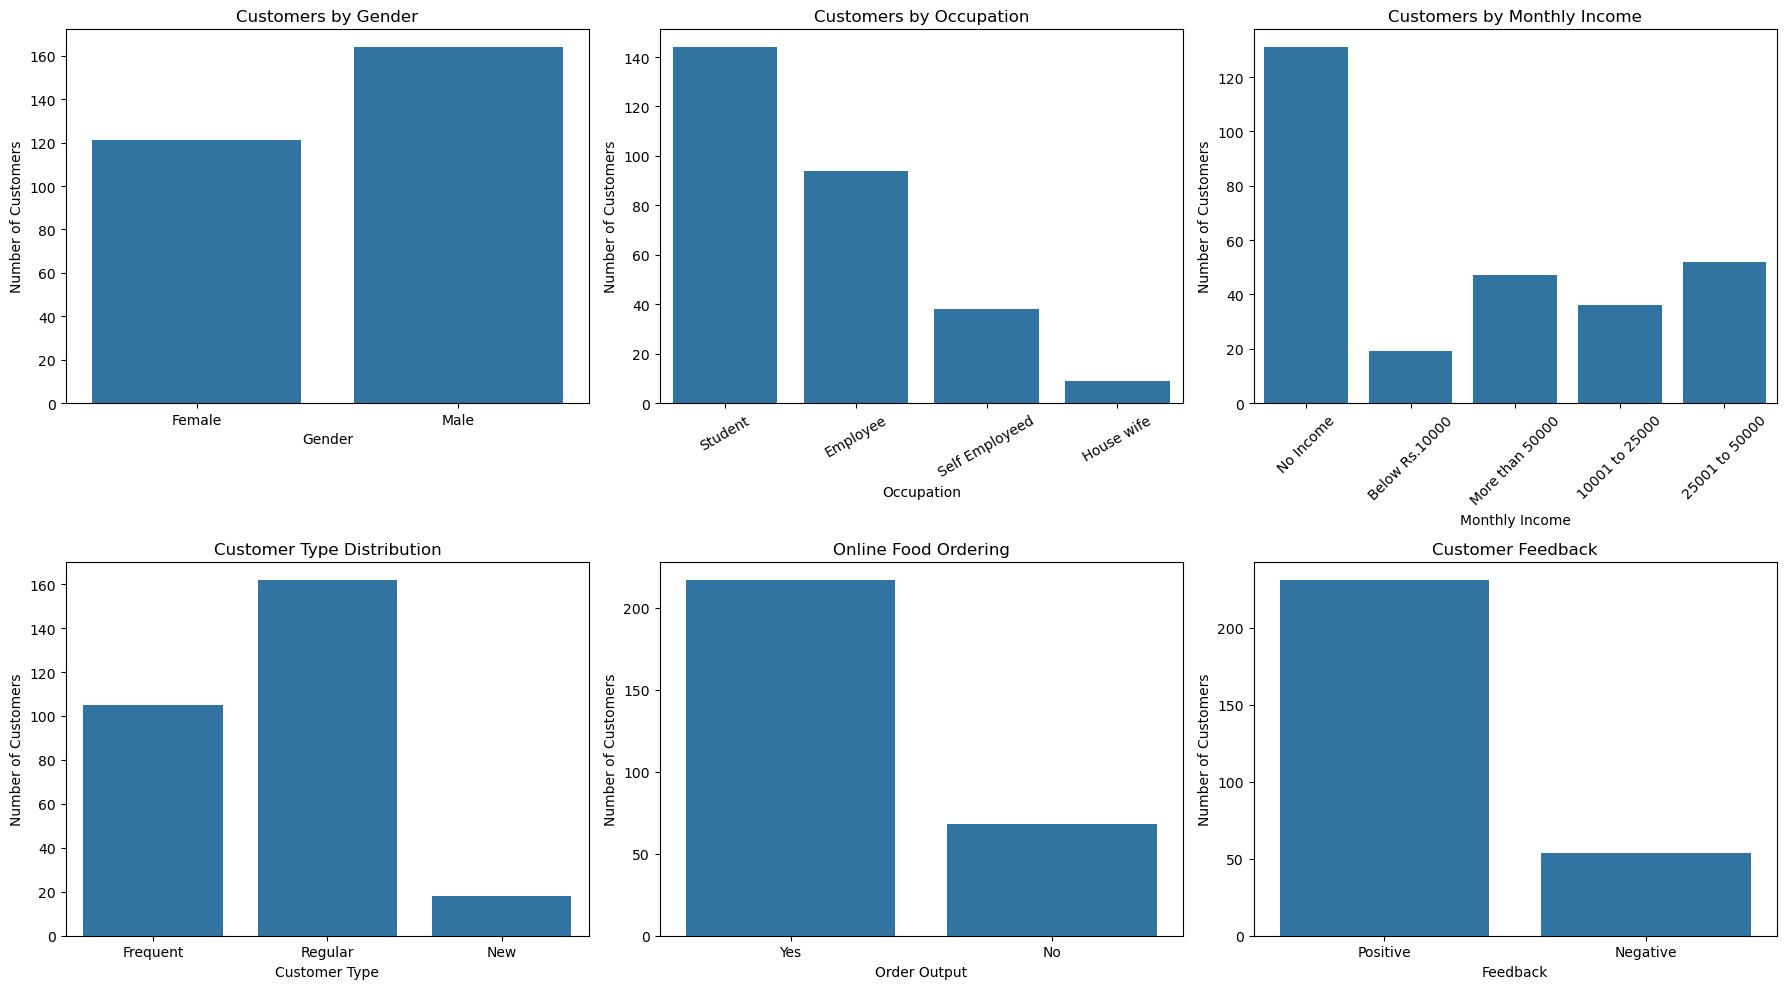

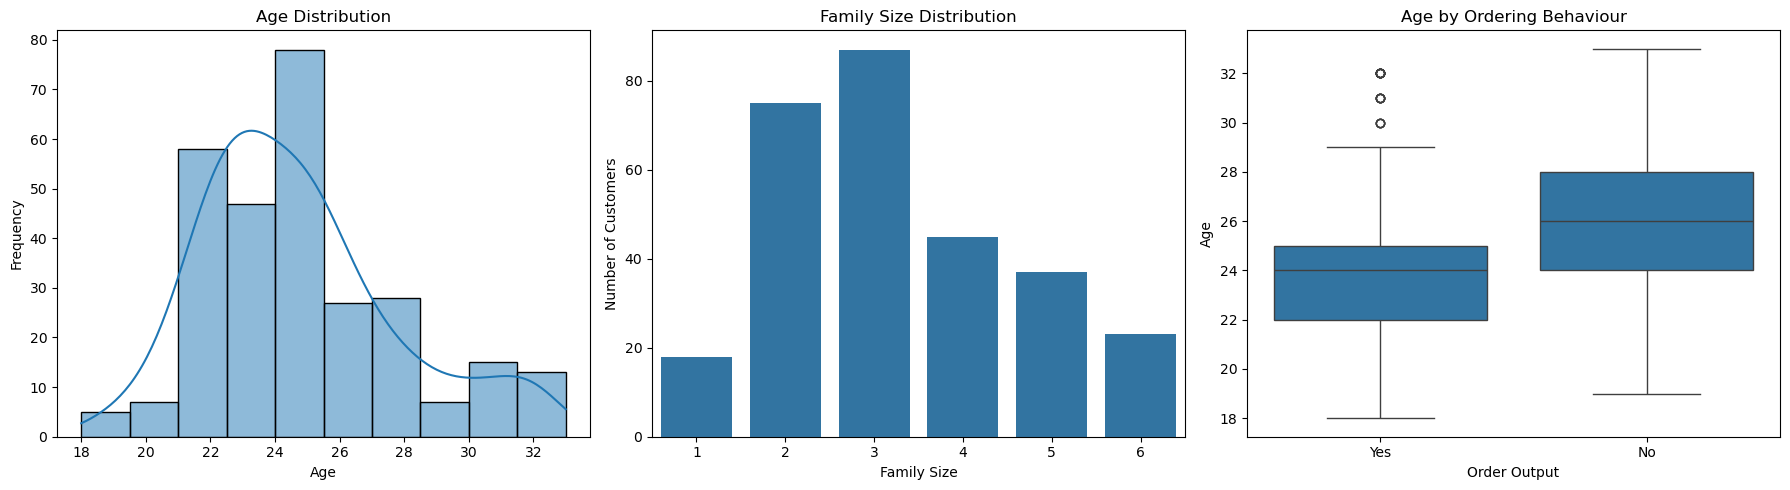


Ordering Percentage by Education:
 Output                         No    Yes
Educational Qualifications              
Graduate                    29.37  70.63
Ph.D                        33.33  66.67
Post Graduate               16.80  83.20
School                      18.18  81.82
Uneducated                  50.00  50.00


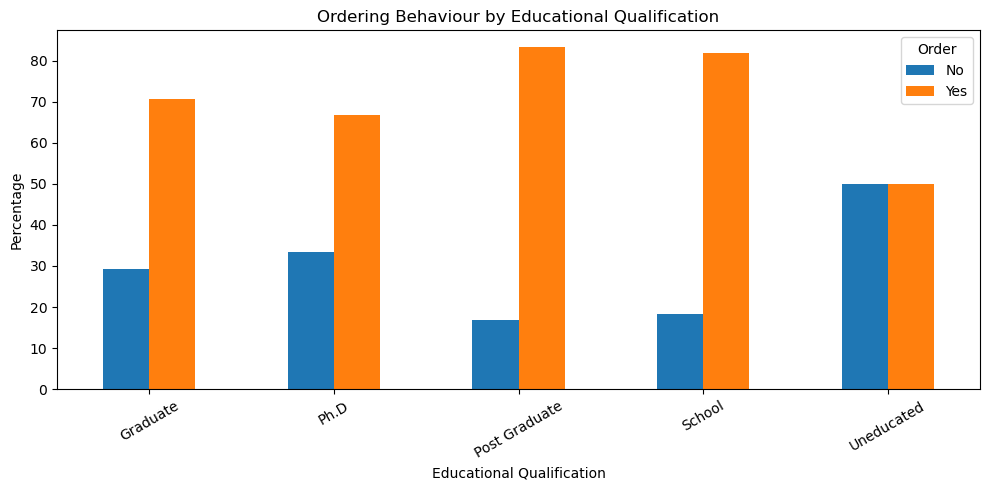


Feedback Percentage by Customer Type:
 Feedback       Negative  Positive
Customer Type                    
Frequent          19.05     80.95
New               22.22     77.78
Regular           18.52     81.48


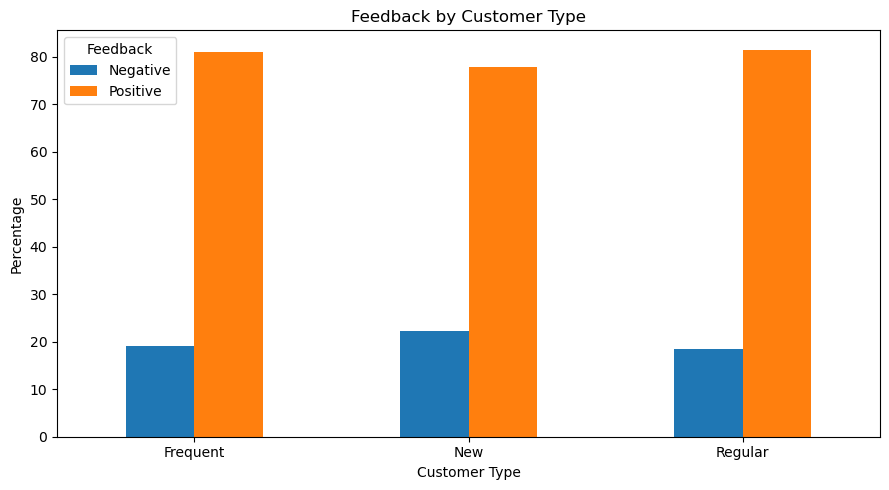


Ordering Percentage by Gender:
 Output     No    Yes
Gender              
Female  25.62  74.38
Male    22.56  77.44


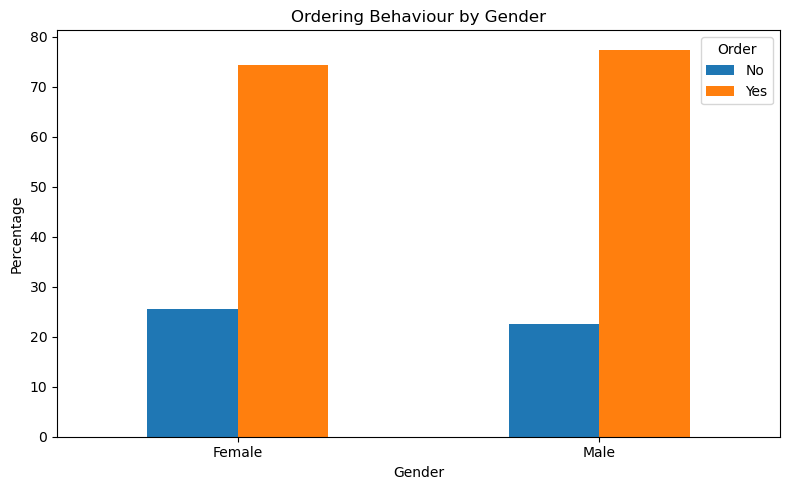


Correlation Matrix:
                   Age  Family size
Age          1.000000     0.212541
Family size  0.212541     1.000000


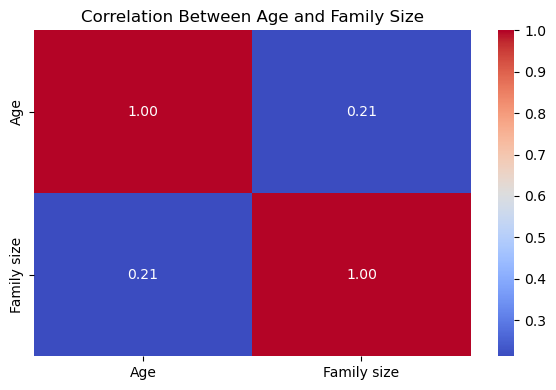

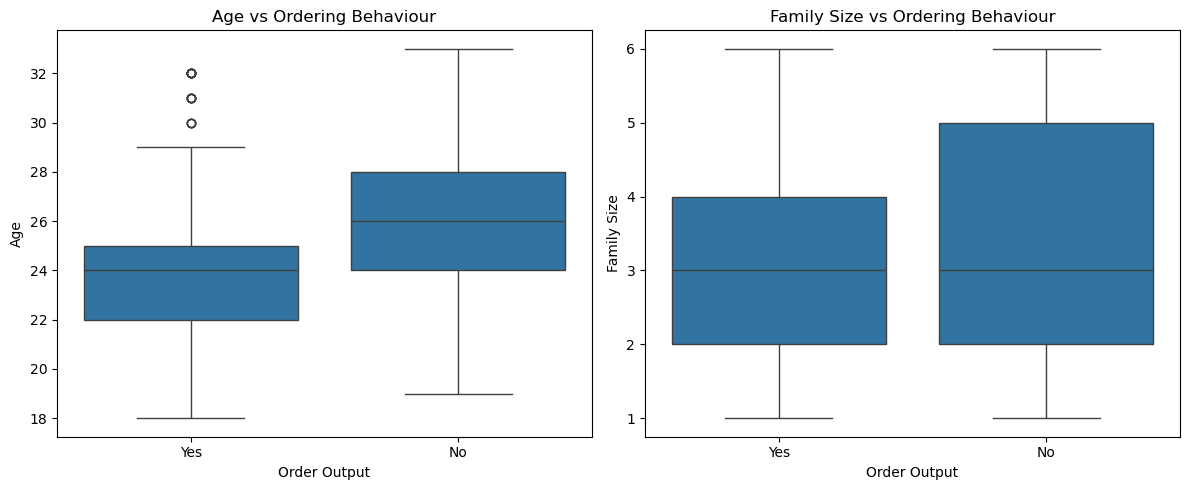


========== CHI-SQUARE TEST ==========
Gender vs Ordering Behaviour
Chi-square: 0.21
p-value: 0.6468
Conclusion: No significant association between gender and ordering behaviour.

========== CHI-SQUARE TEST ==========
Customer Type vs Feedback
Chi-square: 0.1458
p-value: 0.9297
Conclusion: No significant association between customer type and feedback.

========== T-TEST ==========
Age and Ordering Behaviour
Average Age - Yes: 24.29
Average Age - No: 25.9
t-statistic: -3.8839
p-value: 0.0002
Conclusion: Mean age differs significantly between the two groups.

========== PEARSON CORRELATION ==========
Correlation coefficient: 0.2125
p-value: 0.0003
Conclusion: Age and family size have a significant linear relationship.

FINAL PROJECT SUMMARY
Total Customers: 285
Average Age: 24.68
Average Family Size: 3.27
Order Yes: 217
Order No: 68
Positive Feedback: 231
Negative Feedback: 54
Most Common Customer Type: Regular
Most Common Occupation: Student


In [3]:
# ============================================================
# ONLINE FOOD ORDERING DATA ANALYSIS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, ttest_ind, pearsonr

# ============================================================
# 1. LOAD DATA
# ============================================================
df = pd.read_csv(r"C:\Users\victu\Downloads\online food ordering dataset\online food delivery dataset.csv")
df = df.drop(columns=["Unnamed: 13"])
df["Feedback"] = df["Feedback"].str.strip()

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:\n", df.head())
print("\nColumns:\n", df.columns.tolist())

# ============================================================
# 2. DATA CLEANING
# ============================================================
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())
df = df.drop_duplicates()

# ============================================================
# 3. DATA TYPES AND DESCRIPTIVE STATISTICS
# ============================================================
print("\nData Types:\n", df.dtypes)
print("\nDescriptive Statistics:\n", df.describe())

# ============================================================
# 4. FREQUENCY ANALYSIS
# ============================================================
categorical_cols = ["Gender","Marital Status","Occupation","Monthly Income","Educational Qualifications","Customer Type","Output","Feedback"]

for col in categorical_cols:
    print(f"\n{col}:\n", df[col].value_counts())

# ============================================================
# 5. KEY SUMMARY
# ============================================================
print("\n========== KEY SUMMARY ==========")
print("Total Customers:", len(df))
print("Average Age:", round(df["Age"].mean(),2))
print("Average Family Size:", round(df["Family size"].mean(),2))
print("Most Common Gender:", df["Gender"].mode()[0])
print("Most Common Occupation:", df["Occupation"].mode()[0])
print("Most Common Customer Type:", df["Customer Type"].mode()[0])
print("Order Yes Percentage:", round((df["Output"]=="Yes").mean()*100,2),"%")
print("Positive Feedback Percentage:", round((df["Feedback"]=="Positive").mean()*100,2),"%")
print("=================================")

# ============================================================
# 6. MAIN VISUAL ANALYSIS
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18,10))

sns.countplot(data=df, x="Gender", ax=axes[0,0])
axes[0,0].set_title("Customers by Gender")
axes[0,0].set_xlabel("Gender")
axes[0,0].set_ylabel("Number of Customers")

sns.countplot(data=df, x="Occupation", ax=axes[0,1])
axes[0,1].set_title("Customers by Occupation")
axes[0,1].set_xlabel("Occupation")
axes[0,1].set_ylabel("Number of Customers")
axes[0,1].tick_params(axis="x", rotation=30)

sns.countplot(data=df, x="Monthly Income", ax=axes[0,2])
axes[0,2].set_title("Customers by Monthly Income")
axes[0,2].set_xlabel("Monthly Income")
axes[0,2].set_ylabel("Number of Customers")
axes[0,2].tick_params(axis="x", rotation=45)

sns.countplot(data=df, x="Customer Type", ax=axes[1,0])
axes[1,0].set_title("Customer Type Distribution")
axes[1,0].set_xlabel("Customer Type")
axes[1,0].set_ylabel("Number of Customers")

sns.countplot(data=df, x="Output", ax=axes[1,1])
axes[1,1].set_title("Online Food Ordering")
axes[1,1].set_xlabel("Order Output")
axes[1,1].set_ylabel("Number of Customers")

sns.countplot(data=df, x="Feedback", ax=axes[1,2])
axes[1,2].set_title("Customer Feedback")
axes[1,2].set_xlabel("Feedback")
axes[1,2].set_ylabel("Number of Customers")

plt.tight_layout()
plt.show()

# ============================================================
# 7. AGE AND FAMILY SIZE ANALYSIS
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.histplot(df["Age"], bins=10, kde=True, ax=axes[0])
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Frequency")

sns.countplot(data=df, x="Family size", ax=axes[1])
axes[1].set_title("Family Size Distribution")
axes[1].set_xlabel("Family Size")
axes[1].set_ylabel("Number of Customers")

sns.boxplot(data=df, x="Output", y="Age", ax=axes[2])
axes[2].set_title("Age by Ordering Behaviour")
axes[2].set_xlabel("Order Output")
axes[2].set_ylabel("Age")

plt.tight_layout()
plt.show()

# ============================================================
# 8. EDUCATION AND ORDERING BEHAVIOUR
# ============================================================
education_output = pd.crosstab(df["Educational Qualifications"], df["Output"], normalize="index")*100
print("\nOrdering Percentage by Education:\n", education_output.round(2))

education_output.plot(kind="bar", figsize=(10,5))
plt.title("Ordering Behaviour by Educational Qualification")
plt.xlabel("Educational Qualification")
plt.ylabel("Percentage")
plt.xticks(rotation=30)
plt.legend(title="Order")
plt.tight_layout()
plt.show()

# ============================================================
# 9. CUSTOMER TYPE AND FEEDBACK
# ============================================================
customer_feedback = pd.crosstab(df["Customer Type"], df["Feedback"], normalize="index")*100
print("\nFeedback Percentage by Customer Type:\n", customer_feedback.round(2))

customer_feedback.plot(kind="bar", figsize=(9,5))
plt.title("Feedback by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Feedback")
plt.tight_layout()
plt.show()

# ============================================================
# 10. GENDER AND ORDERING BEHAVIOUR
# ============================================================
gender_output = pd.crosstab(df["Gender"], df["Output"], normalize="index")*100
print("\nOrdering Percentage by Gender:\n", gender_output.round(2))

gender_output.plot(kind="bar", figsize=(8,5))
plt.title("Ordering Behaviour by Gender")
plt.xlabel("Gender")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Order")
plt.tight_layout()
plt.show()

# ============================================================
# 11. CORRELATION ANALYSIS
# ============================================================
numeric_cols = ["Age","Family size"]
correlation = df[numeric_cols].corr()

print("\nCorrelation Matrix:\n", correlation)

plt.figure(figsize=(6,4))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Between Age and Family Size")
plt.tight_layout()
plt.show()

# ============================================================
# 12. AGE AND FAMILY SIZE VS ORDERING
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.boxplot(data=df, x="Output", y="Age", ax=axes[0])
axes[0].set_title("Age vs Ordering Behaviour")
axes[0].set_xlabel("Order Output")
axes[0].set_ylabel("Age")

sns.boxplot(data=df, x="Output", y="Family size", ax=axes[1])
axes[1].set_title("Family Size vs Ordering Behaviour")
axes[1].set_xlabel("Order Output")
axes[1].set_ylabel("Family Size")

plt.tight_layout()
plt.show()

# ============================================================
# 13. CHI-SQUARE TEST: GENDER VS ORDERING
# ============================================================
table = pd.crosstab(df["Gender"], df["Output"])
chi2, p, dof, expected = chi2_contingency(table)

print("\n========== CHI-SQUARE TEST ==========")
print("Gender vs Ordering Behaviour")
print("Chi-square:", round(chi2,4))
print("p-value:", round(p,4))

if p < 0.05:
    print("Conclusion: Gender and ordering behaviour are significantly associated.")
else:
    print("Conclusion: No significant association between gender and ordering behaviour.")

# ============================================================
# 14. CHI-SQUARE TEST: CUSTOMER TYPE VS FEEDBACK
# ============================================================
table = pd.crosstab(df["Customer Type"], df["Feedback"])
chi2, p, dof, expected = chi2_contingency(table)

print("\n========== CHI-SQUARE TEST ==========")
print("Customer Type vs Feedback")
print("Chi-square:", round(chi2,4))
print("p-value:", round(p,4))

if p < 0.05:
    print("Conclusion: Customer type and feedback are significantly associated.")
else:
    print("Conclusion: No significant association between customer type and feedback.")

# ============================================================
# 15. T-TEST: AGE VS ORDERING
# ============================================================
age_yes = df.loc[df["Output"]=="Yes","Age"]
age_no = df.loc[df["Output"]=="No","Age"]

t_stat, p_value = ttest_ind(age_yes, age_no, equal_var=False)

print("\n========== T-TEST ==========")
print("Age and Ordering Behaviour")
print("Average Age - Yes:", round(age_yes.mean(),2))
print("Average Age - No:", round(age_no.mean(),2))
print("t-statistic:", round(t_stat,4))
print("p-value:", round(p_value,4))

if p_value < 0.05:
    print("Conclusion: Mean age differs significantly between the two groups.")
else:
    print("Conclusion: No significant difference in mean age.")

# ============================================================
# 16. PEARSON CORRELATION TEST
# ============================================================
r, p = pearsonr(df["Age"], df["Family size"])

print("\n========== PEARSON CORRELATION ==========")
print("Correlation coefficient:", round(r,4))
print("p-value:", round(p,4))

if p < 0.05:
    print("Conclusion: Age and family size have a significant linear relationship.")
else:
    print("Conclusion: No significant linear relationship between age and family size.")

# ============================================================
# 17. FINAL SUMMARY
# ============================================================
print("\n============================================")
print("FINAL PROJECT SUMMARY")
print("============================================")
print("Total Customers:", len(df))
print("Average Age:", round(df["Age"].mean(),2))
print("Average Family Size:", round(df["Family size"].mean(),2))
print("Order Yes:", (df["Output"]=="Yes").sum())
print("Order No:", (df["Output"]=="No").sum())
print("Positive Feedback:", (df["Feedback"]=="Positive").sum())
print("Negative Feedback:", (df["Feedback"]=="Negative").sum())
print("Most Common Customer Type:", df["Customer Type"].mode()[0])
print("Most Common Occupation:", df["Occupation"].mode()[0])
print("============================================")